<a href="https://colab.research.google.com/github/ninque34/Spotify-analiza/blob/main/Spotify_dataset_analiza_danych_i_modele_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Przewidywanie użytkowników Spotify Premium**

In [ ]:
!wget https://raw.githubusercontent.com/ninque34/Spotify-analiza/refs/heads/main/spotify_churn_dataset.csv

--2026-06-10 10:20:08--  https://raw.githubusercontent.com/ninque34/Spotify-analiza/refs/heads/main/spotify_churn_dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 391588 (382K) [text/plain]
Saving to: ‘spotify_churn_dataset.csv.2’

spotify_churn_datas 100%[===================>] 382.41K  --.-KB/s    in 0.04s   

2026-06-10 10:20:08 (9.42 MB/s) - ‘spotify_churn_dataset.csv.2’ saved [391588/391588]



In [ ]:
!ls

sample_data		   spotify_churn_dataset.csv.1
spotify_churn_dataset.csv  spotify_churn_dataset.csv.2


## import bibliotek i wczytanie danych

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


def load_spotify_data(spotify_path="spotify_churn_dataset.csv"):
  # csv_path = os.path.join(Spotify_path, ".csv")
  return pd.read_csv(spotify_path, encoding='latin1')

spotify = load_spotify_data()

# podgląd danych

In [ ]:
spotify.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [ ]:
spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   object 
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_listening      8000 non-null   int64  
 11  is_churned             8000 non-null   int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 750.1+ KB


In [ ]:
spotify.isnull().sum()

,0
user_id,0
gender,0
age,0
country,0
subscription_type,0
listening_time,0
songs_played_per_day,0
skip_rate,0
device_type,0
ads_listened_per_week,0


baza danych nie zawiera brakujących wartości

In [ ]:
spotify.describe()

,user_id,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,37.662125,154.068250,50.127250,0.300127,6.943875,0.747750,0.258875
std,2309.54541,12.740359,84.015596,28.449762,0.173594,13.617953,0.434331,0.438044
min,1.00000,16.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2000.75000,26.000000,81.000000,25.000000,0.150000,0.000000,0.000000,0.000000
50%,4000.50000,38.000000,154.000000,50.000000,0.300000,0.000000,1.000000,0.000000
75%,6000.25000,49.000000,227.000000,75.000000,0.450000,5.000000,1.000000,1.000000
max,8000.00000,59.000000,299.000000,99.000000,0.600000,49.000000,1.000000,1.000000


In [ ]:
spotify.columns

Index(['user_id', 'gender', 'age', 'country', 'subscription_type',
       'listening_time', 'songs_played_per_day', 'skip_rate', 'device_type',
       'ads_listened_per_week', 'offline_listening', 'is_churned'],
      dtype='object')

# wykresy

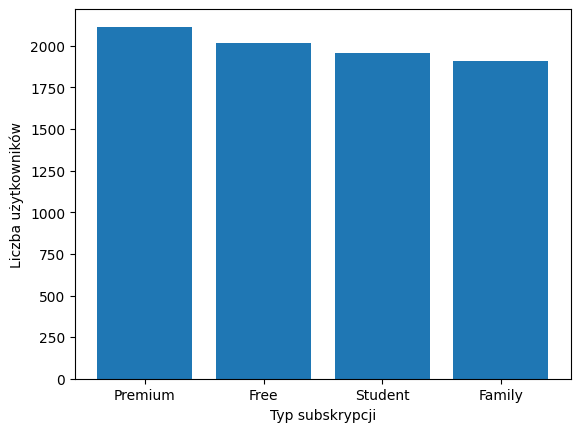

In [ ]:
#wykres liczby użytkowników według typu subskrypcji

plt.bar(spotify["subscription_type"].value_counts().index, spotify["subscription_type"].value_counts().values)

plt.xlabel("Typ subskrypcji")
plt.ylabel("Liczba użytkowników")

plt.show()

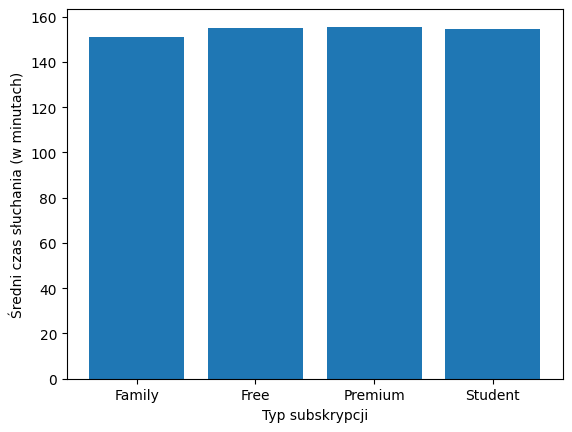

In [ ]:
#średni czas słuchania dla każdego typu subskrypcji

sredni_czas = spotify.groupby("subscription_type")["listening_time"].mean()

plt.bar(sredni_czas.index, sredni_czas.values)

plt.xlabel("Typ subskrypcji")
plt.ylabel("Średni czas słuchania (w minutach)")

plt.show()

Użytkownicy płatnych planów mają średnio większy listening time. Nie jest to jednnak wielka różnica.

# Tworzenie zmiennej docelowej

In [ ]:
def make_premium(x):
  if x == "Free":
    return 0
  else:
    return 1

spotify["is_premium"] = spotify["subscription_type"].apply(make_premium)

# celem tego przekształcenia jest uproszczenie problemu (typy subskrypcji) do klasyfikacji binarnej (Free(0)/Premium(0))

In [ ]:
x = spotify.drop(["subscription_type", "is_premium"], axis=1) #usuwamy te kolumny (axis 1 to "usuń kolumnę", 0 to wiersz)
y = spotify["is_premium"]

#chcemy przewidzieć, czy ktoś ma płatny plan
# x - cechy użytkowników
# y - zmienna docelowa


In [ ]:
x = pd.get_dummies(x)

# zamiana tekstu na wartości liczbowe 0/1 (modele uczenia maszynowego wymagają danych liczbowych)

# Podział danych

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Dane zostały podzielone:
# 80% - trening
# 20% - test

# Model 1. - Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(x_train, y_train)

lr_pred = lr_model.predict(x_test)

# Model 2. - Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)

# Ocena modeli

In [ ]:
from sklearn.metrics import classification_report

print("LOGISTIC REGRESSION")

print(classification_report(y_test, lr_pred))

print("RANDOM FOREST")

print(classification_report(y_test, rf_pred))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       419
           1       1.00      1.00      1.00      1181

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600

RANDOM FOREST
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       419
           1       1.00      1.00      1.00      1181

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



Porównano dwa modele klasyfikacyjne:
- Logistic Regression
- Random Forest

Oba modele osiągnęły podobne wyniki.
Może to oznaczać, że dane są dobrze separowalne i nawet prostszy model dobrze radzi sobie z klasyfikacją użytkowników.